# 05 — Spatial Validation and Model Tuning

## Objective

This notebook improves the crop-classification analysis by:

- reviewing the prepared geospatial dataset;
- creating a reproducible geographical train/test split;
- tuning the random forest model;
- comparing ordinary accuracy with balanced accuracy and macro F1;
- examining performance across individual crop classes;
- identifying the most influential predictive features;
- mapping actual and predicted 2025 crop classifications.

The target is the 2025 crop classification, using information available from 2024 and the geographical position of each CROME cell.

In [3]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 1. Load and inspect the prepared data

The prepared GeoPackage contains the matched 2024 and 2025 CROME observations and their geographic geometry.

In [5]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_root = current_folder
elif (current_folder.parent / "data").exists():
    project_root = current_folder.parent
else:
    raise FileNotFoundError("The project data folder could not be located.")

data_path = project_root / "data" / "interim" / "crome_prepared_data.gpkg"

print(f"Current folder: {current_folder}")
print(f"Project root: {project_root}")
print(f"Data file: {data_path}")
print(f"File exists: {data_path.exists()}")

Current folder: /Users/dafyddjones/projects/lincolnshire-crop-prediction
Project root: /Users/dafyddjones/projects/lincolnshire-crop-prediction
Data file: /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/interim/crome_prepared_data.gpkg
File exists: True


In [6]:
gdf = gpd.read_file(data_path)

print(f"Rows: {gdf.shape[0]:,}")
print(f"Columns: {gdf.shape[1]}")
print(f"CRS: {gdf.crs}")

print("\nColumn names:")
print(gdf.columns.tolist())

gdf.head()

Rows: 4,868
Columns: 9
CRS: EPSG:4326

Column names:
['cromeid', 'lucode_2024', 'land_use_2024', 'confidence_2024', 'easting', 'northing', 'target_2025', 'target_name_2025', 'geometry']


,cromeid,lucode_2024,land_use_2024,confidence_2024,easting,northing,target_2025,target_name_2025,geometry
0,RPA512626340510,PG01,Grass,0.320,512626.778605,340512.123903,AC66,Winter Wheat,"POLYGON ((-0.32484 52.94986, -0.32544 52.94987..."
1,RPA513046344216,AC66,Winter Wheat,0.297,513046.696018,344218.716060,AC66,Winter Wheat,"POLYGON ((-0.31699 52.98339, -0.3173 52.98308,..."
2,RPA512026344112,AC66,Winter Wheat,0.577,512026.721345,344114.825388,AC03,Beet,"POLYGON ((-0.33312 52.98237, -0.33341 52.98268..."
3,RPA512386340579,FA01,Fallow Land,0.182,512386.762061,340581.398936,AC66,Winter Wheat,"POLYGON ((-0.32808 52.95084, -0.32839 52.95054..."
4,RPA513286341168,AC66,Winter Wheat,0.462,513286.771223,341170.282658,LG20,Winter Field beans,"POLYGON ((-0.31479 52.95564, -0.31539 52.95565..."


## 2. Validate the modelling fields

Before modelling, check for missing values, duplicated CROME identifiers and class imbalance in the 2025 target.

In [7]:
model_columns = [
    "cromeid",
    "lucode_2024",
    "confidence_2024",
    "easting",
    "northing",
    "target_2025"
]

print("Missing values:")
display(gdf[model_columns].isna().sum().to_frame("missing"))

print(f"Duplicated CROME IDs: {gdf['cromeid'].duplicated().sum():,}")
print(f"Number of target classes: {gdf['target_2025'].nunique()}")

target_distribution = (
    gdf["target_2025"]
    .value_counts()
    .rename_axis("target_2025")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(gdf) * 100
).round(1)

display(target_distribution)

Missing values:


,missing
cromeid,0
lucode_2024,0
confidence_2024,0
easting,0
northing,0
target_2025,0


Duplicated CROME IDs: 0
Number of target classes: 13


,target_2025,count,percentage
0,AC66,2254,46.3
1,CA02,540,11.1
2,FA01,294,6.0
3,AC67,289,5.9
4,NA01,266,5.5
5,PG01,252,5.2
6,AC17,155,3.2
7,LG20,153,3.1
8,AC01,146,3.0
9,AC03,143,2.9


## 3. Create spatial validation blocks

Randomly splitting geographical observations can produce overly optimistic results because neighbouring locations may be very similar. To reduce this spatial leakage, the study area is divided into one-kilometre blocks.

All observations within a block will remain together during model validation.

In [8]:
BLOCK_SIZE = 1_000

gdf_model = gdf.copy()

gdf_model["easting_block"] = (
    (gdf_model["easting"] - gdf_model["easting"].min()) // BLOCK_SIZE
).astype(int)

gdf_model["northing_block"] = (
    (gdf_model["northing"] - gdf_model["northing"].min()) // BLOCK_SIZE
).astype(int)

gdf_model["spatial_block"] = (
    gdf_model["easting_block"].astype(str)
    + "_"
    + gdf_model["northing_block"].astype(str)
)

print(
    f"Easting range: {gdf_model['easting'].min():,.0f} "
    f"to {gdf_model['easting'].max():,.0f}"
)

print(
    f"Northing range: {gdf_model['northing'].min():,.0f} "
    f"to {gdf_model['northing'].max():,.0f}"
)

print(f"Number of spatial blocks: {gdf_model['spatial_block'].nunique()}")

display(
    gdf_model["spatial_block"]
    .value_counts()
    .describe()
    .to_frame("observations_per_block")
)

Task was destroyed but it is pending!
task: <Task pending name='Task-98' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-99' coro=<Kernel.shell_main() running at /Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/pandas/core/indexers/utils.py:425: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  key = tuple(k for k in key if k is not Ellipsis and k is not np.newaxis)
Task was destroyed but it is pending!
task: <Task pending name='Task-99' coro=<K

Easting range: 510,827 to 514,307
Northing range: 340,443 to 346,124
Number of spatial blocks: 24


,observations_per_block
count,24.000000
mean,202.833333
std,53.680752
min,89.000000
25%,153.500000
50%,232.000000
75%,246.000000
max,247.000000


## 4. Define the geographical test area

The easternmost column of one-kilometre blocks is held back as the final test area. This provides a more demanding and realistic assessment than randomly selecting individual observations.

The held-out area will not be used during model tuning.

In [9]:
easternmost_block = gdf_model["easting_block"].max()

test_mask = gdf_model["easting_block"] == easternmost_block

train_gdf = gdf_model.loc[~test_mask].copy()
test_gdf = gdf_model.loc[test_mask].copy()

print(f"Training observations: {len(train_gdf):,} ({len(train_gdf) / len(gdf_model):.1%})")
print(f"Test observations: {len(test_gdf):,} ({len(test_gdf) / len(gdf_model):.1%})")

print(f"\nTraining spatial blocks: {train_gdf['spatial_block'].nunique()}")
print(f"Test spatial blocks: {test_gdf['spatial_block'].nunique()}")

print(f"\nTraining target classes: {train_gdf['target_2025'].nunique()}")
print(f"Test target classes: {test_gdf['target_2025'].nunique()}")

classes_missing_from_test = sorted(
    set(train_gdf["target_2025"]) - set(test_gdf["target_2025"])
)

print(f"Classes missing from test area: {classes_missing_from_test}")

Training observations: 4,126 (84.8%)
Test observations: 742 (15.2%)

Training spatial blocks: 18
Test spatial blocks: 6

Training target classes: 13
Test target classes: 13
Classes missing from test area: []


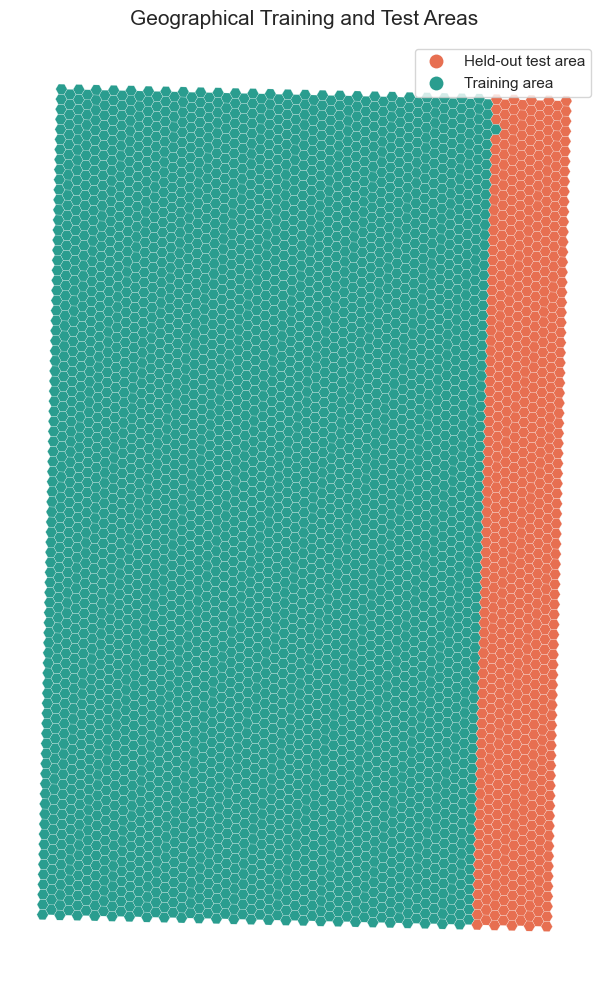

In [10]:
from matplotlib.colors import ListedColormap

split_gdf = gdf_model.copy()

split_gdf["dataset_split"] = np.where(
    test_mask,
    "Held-out test area",
    "Training area"
)

fig, ax = plt.subplots(figsize=(9, 10))

split_gdf.plot(
    column="dataset_split",
    categorical=True,
    cmap=ListedColormap(["#e76f51", "#2a9d8f"]),
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    ax=ax
)

ax.set_title(
    "Geographical Training and Test Areas",
    fontsize=15,
    pad=12
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

## 5. Prepare the modelling pipeline

The 2024 crop code is categorical and will be one-hot encoded. Confidence and spatial coordinates are retained as numeric predictors.

The preprocessing and random forest model are combined in one pipeline to ensure that transformations are learned from the training data only.

In [11]:
feature_columns = [
    "lucode_2024",
    "confidence_2024",
    "easting",
    "northing"
]

categorical_features = ["lucode_2024"]

numeric_features = [
    "confidence_2024",
    "easting",
    "northing"
]

X_train = train_gdf[feature_columns]
y_train = train_gdf["target_2025"]

X_test = test_gdf[feature_columns]
y_test = test_gdf["target_2025"]

training_groups = train_gdf["spatial_block"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "crop_code",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Training groups: {training_groups.nunique()}")
print(
    "Shared blocks between training and test:",
    len(
        set(train_gdf["spatial_block"])
        & set(test_gdf["spatial_block"])
    )
)

X_train shape: (4126, 4)
X_test shape: (742, 4)
Training groups: 18
Shared blocks between training and test: 0


## 6. Tune the random forest with grouped cross-validation

Five-fold grouped cross-validation is used within the training area. Entire spatial blocks are allocated to folds, so neighbouring observations remain together.

The model is selected using macro F1 because the target classes are substantially imbalanced. Accuracy and balanced accuracy are retained as supporting measures.

In [12]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

parameter_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 12],
    "model__min_samples_leaf": [1, 3],
    "model__class_weight": [None, "balanced_subsample"]
}

group_cv = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=parameter_grid,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro"
    },
    refit="macro_f1",
    cv=group_cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train,
    groups=training_groups
)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/dafyddjones/.pyenv/versions/3.12.9/envs/lewagon_current/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/dafyddjones/.pyenv/versions/3

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced_subsample'], 'model__max_depth': [None, 12], 'model__min_samples_leaf': [1, 3], 'model__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'macro_f1': 'f1_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'macro_f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",GroupKF

In [13]:
print("Best parameters:")
for parameter, value in grid_search.best_params_.items():
    print(f"  {parameter}: {value}")

print(
    f"\nBest mean cross-validation macro F1: "
    f"{grid_search.best_score_:.3f}"
)

cv_results = pd.DataFrame(grid_search.cv_results_)

results_summary = (
    cv_results[
        [
            "params",
            "mean_test_accuracy",
            "mean_test_balanced_accuracy",
            "mean_test_macro_f1",
            "std_test_macro_f1"
        ]
    ]
    .sort_values("mean_test_macro_f1", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(results_summary)

Best parameters:
  model__class_weight: balanced_subsample
  model__max_depth: 12
  model__min_samples_leaf: 1
  model__n_estimators: 200

Best mean cross-validation macro F1: 0.344


,params,mean_test_accuracy,mean_test_balanced_accuracy,mean_test_macro_f1,std_test_macro_f1
0,"{'model__class_weight': 'balanced_subsample', ...",0.570460,0.379187,0.343643,0.032848
1,"{'model__class_weight': 'balanced_subsample', ...",0.571178,0.376175,0.339448,0.038557
2,"{'model__class_weight': 'balanced_subsample', ...",0.564143,0.379577,0.337272,0.040277
3,"{'model__class_weight': None, 'model__max_dept...",0.590541,0.362451,0.336943,0.024941
4,"{'model__class_weight': 'balanced_subsample', ...",0.558303,0.377045,0.336319,0.039583
5,"{'model__class_weight': 'balanced_subsample', ...",0.589734,0.360270,0.335922,0.031579
6,"{'model__class_weight': 'balanced_subsample', ...",0.590621,0.361567,0.335714,0.031748
7,"{'model__class_weight': None, 'model__max_dept...",0.588248,0.356371,0.328126,0.028883
8,"{'model__class_weight': 'balanced_subsample', ...",0.534520,0.383904,0.326615,0.043638
9,"{'model__class_weight': 'balanced_subsample', ...",0.534221,0.383075,0.326095,0.039780


## 7. Evaluate the tuned model on the held-out area

After parameter selection, the fitted best model is evaluated once on the untouched eastern test area. These results provide the final estimate of performance on a geographically separate location.

In [14]:
best_model = grid_search.best_estimator_

test_predictions = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, test_predictions)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_predictions
)

test_macro_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

final_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Balanced accuracy",
            "Macro F1"
        ],
        "Score": [
            test_accuracy,
            test_balanced_accuracy,
            test_macro_f1
        ]
    }
)

final_metrics["Percentage"] = (
    final_metrics["Score"] * 100
).round(1)

display(final_metrics)

,Metric,Score,Percentage
0,Accuracy,0.663073,66.3
1,Balanced accuracy,0.363051,36.3
2,Macro F1,0.336476,33.6


## 8. Performance by crop class

Overall accuracy can conceal weak performance on uncommon crops. Precision, recall and F1 are therefore examined separately for each 2025 crop class.

In [16]:
class_labels = sorted(y_test.unique())

code_to_name = (
    gdf[["target_2025", "target_name_2025"]]
    .drop_duplicates()
    .set_index("target_2025")["target_name_2025"]
    .to_dict()
)

report = classification_report(
    y_test,
    test_predictions,
    labels=class_labels,
    output_dict=True,
    zero_division=0
)

class_report = (
    pd.DataFrame(report)
    .T
    .loc[class_labels, ["precision", "recall", "f1-score", "support"]]
    .reset_index()
    .rename(columns={"index": "crop_code"})
)

class_report.insert(
    1,
    "crop_name",
    class_report["crop_code"].map(code_to_name)
)

class_report["support"] = class_report["support"].astype(int)

display(
    class_report.sort_values(
        "f1-score",
        ascending=False
    ).reset_index(drop=True)
)

,crop_code,crop_name,precision,recall,f1-score,support
0,NA01,Non-vegetated or sparsely-vegetated Land,0.758389,0.949580,0.843284,119
1,AC66,Winter Wheat,0.748092,0.888218,0.812155,331
2,PG01,Grass,0.843750,0.675000,0.750000,40
3,AC67,Winter Oilseed,0.323529,1.000000,0.488889,11
4,CA02,Cover Crop,0.533333,0.303797,0.387097,79
5,AC63,Winter Barley,0.333333,0.333333,0.333333,21
6,FA01,Fallow Land,0.500000,0.195652,0.281250,46
7,WO12,"Trees and Scrubs, short Woody plants, hedgerows",0.444444,0.153846,0.228571,26
8,LG20,Winter Field beans,0.333333,0.125000,0.181818,8
9,OTHER,Other rare land uses,0.052632,0.095238,0.067797,21


### Interpretation

The tuned random forest performs strongly for Non-vegetated Land, Winter Wheat and Grass. Performance is substantially weaker for uncommon crop classes.

Winter Oilseed achieves perfect recall but low precision, indicating that all genuine observations were identified at the cost of numerous false-positive predictions. Spring Barley, Beet and Maize were not identified successfully.

The results demonstrate why ordinary accuracy is insufficient for this imbalanced multiclass problem. Additional predictors—such as neighbouring crop patterns, soil, weather and longer crop histories—would probably be required to distinguish the rare crop classes more reliably.

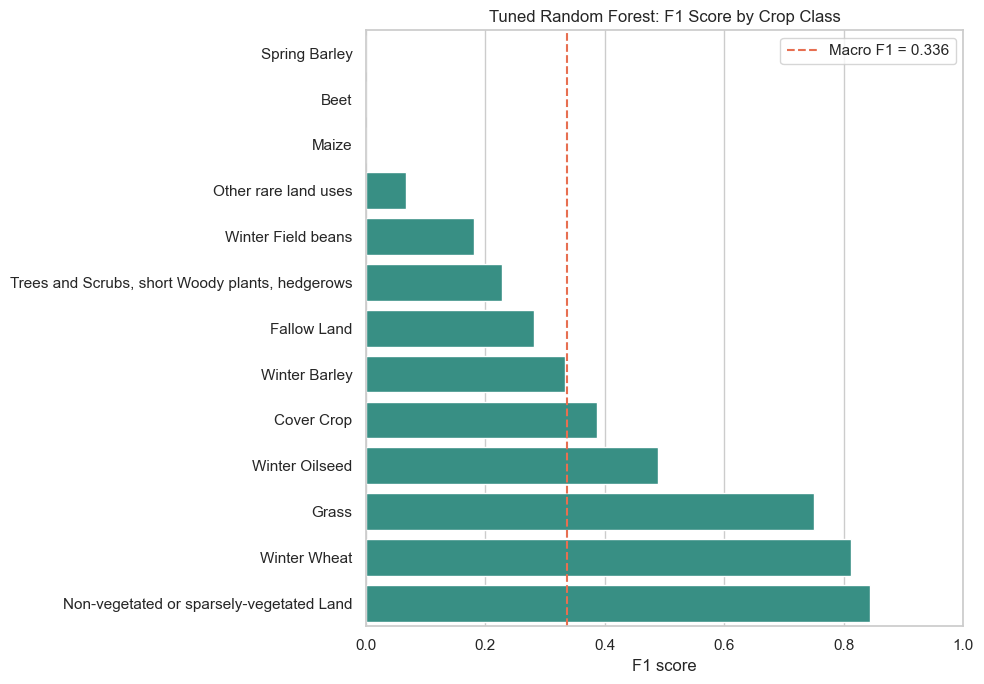

In [17]:
plot_report = class_report.sort_values(
    "f1-score",
    ascending=True
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_report,
    x="f1-score",
    y="crop_name",
    color="#2a9d8f"
)

plt.axvline(
    test_macro_f1,
    color="#e76f51",
    linestyle="--",
    label=f"Macro F1 = {test_macro_f1:.3f}"
)

plt.title("Tuned Random Forest: F1 Score by Crop Class")
plt.xlabel("F1 score")
plt.ylabel("")
plt.xlim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Confusion matrix

The confusion matrix shows the proportion of each true crop class assigned to every predicted class. Values are normalised by the true class, so each row totals approximately 100%.

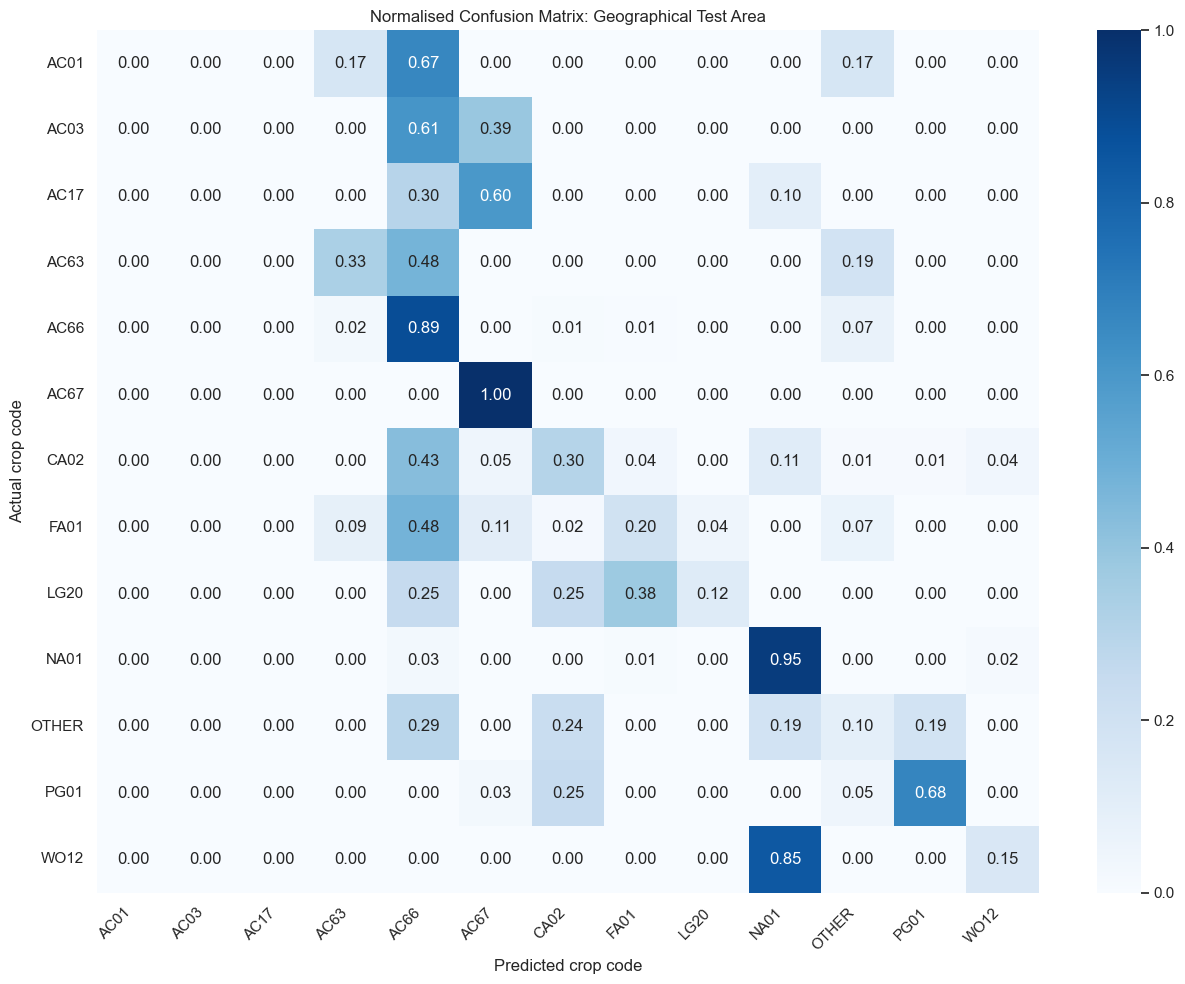

In [18]:
normalised_confusion = confusion_matrix(
    y_test,
    test_predictions,
    labels=class_labels,
    normalize="true"
)

plt.figure(figsize=(13, 10))

sns.heatmap(
    normalised_confusion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    vmin=0,
    vmax=1
)

plt.title("Normalised Confusion Matrix: Geographical Test Area")
plt.xlabel("Predicted crop code")
plt.ylabel("Actual crop code")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 10. Feature importance

Random-forest feature importance estimates how much each transformed predictor contributed to reducing classification uncertainty. One-hot-encoded 2024 crop codes are shown separately, alongside confidence and spatial coordinates.

In [19]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_forest = best_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_forest.feature_importances_
    }
).sort_values("importance", ascending=False)

feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace("crop_code__lucode_2024_", "2024 crop: ", regex=False)
    .str.replace("numeric__", "", regex=False)
)

display(feature_importance.head(15).reset_index(drop=True))

feature_importance["feature_group"] = np.select(
    [
        feature_importance["feature"].str.startswith("2024 crop:"),
        feature_importance["feature"].eq("confidence_2024"),
        feature_importance["feature"].eq("easting"),
        feature_importance["feature"].eq("northing")
    ],
    [
        "2024 crop classification",
        "2024 classification confidence",
        "Easting",
        "Northing"
    ],
    default="Other"
)

grouped_importance = (
    feature_importance
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

grouped_importance["percentage"] = (
    grouped_importance["importance"] * 100
).round(1)

display(grouped_importance.reset_index(drop=True))

,feature,importance
0,northing,0.271533
1,easting,0.232486
2,confidence_2024,0.206992
3,2024 crop: WO12,0.061806
4,2024 crop: NA01,0.059379
5,2024 crop: PG01,0.053184
6,2024 crop: AC66,0.035303
7,2024 crop: AC32,0.017117
8,2024 crop: AC01,0.013561
9,2024 crop: AC17,0.010456


,feature_group,importance,percentage
0,2024 crop classification,0.288988,28.9
1,Northing,0.271533,27.2
2,Easting,0.232486,23.2
3,2024 classification confidence,0.206992,20.7


### Interpretation

Spatial coordinates account for approximately half of the model's total feature importance, showing that crop classification is strongly associated with location within the sampled area. The 2024 crop classification contributes approximately 29%, while the previous classification confidence contributes approximately 21%.

Persistent land-cover categories, including Trees and Scrubs, Non-vegetated Land and Grass, are among the most influential individual crop-code features.

These impurity-based importance values describe how the random forest makes predictions; they should not be interpreted as causal effects. Continuous coordinates may also receive greater importance because they provide many possible decision-tree split points.

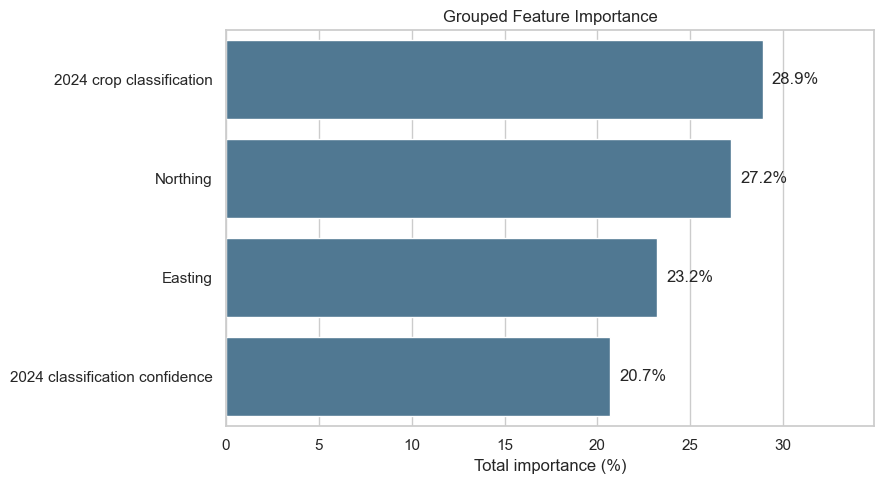

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=grouped_importance,
    x="percentage",
    y="feature_group",
    color="#457b9d"
)

plt.title("Grouped Feature Importance")
plt.xlabel("Total importance (%)")
plt.ylabel("")

for index, value in enumerate(grouped_importance["percentage"]):
    plt.text(
        value + 0.5,
        index,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(0, grouped_importance["percentage"].max() + 6)
plt.tight_layout()
plt.show()

## 11. Map actual and predicted crops

The final geographical comparison shows the true 2025 crop classifications alongside the tuned random forest predictions for the held-out eastern test area. Identical colours represent identical crop codes in both maps.

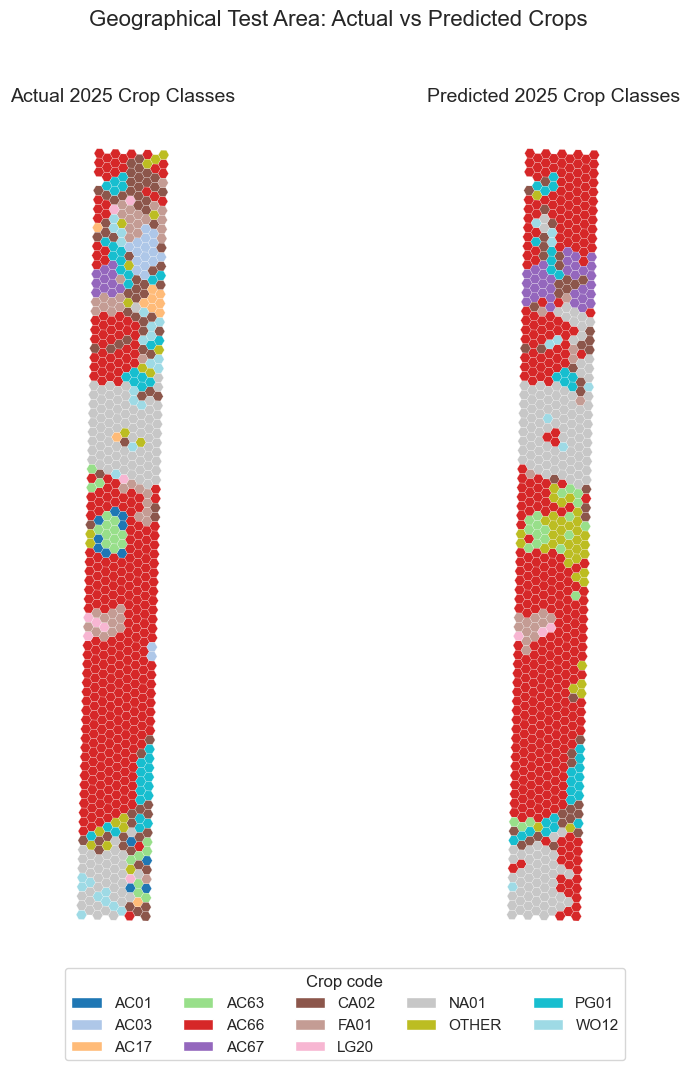

In [21]:
from matplotlib.patches import Patch

test_results = test_gdf.copy()
test_results["predicted_2025"] = test_predictions

colour_values = plt.cm.tab20(
    np.linspace(0, 1, len(class_labels))
)

class_colours = dict(
    zip(class_labels, colour_values)
)

actual_colours = test_results["target_2025"].map(
    class_colours
)

predicted_colours = test_results["predicted_2025"].map(
    class_colours
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 11)
)

test_results.plot(
    color=actual_colours,
    edgecolor="white",
    linewidth=0.15,
    ax=axes[0]
)

axes[0].set_title(
    "Actual 2025 Crop Classes",
    fontsize=14
)
axes[0].set_axis_off()

test_results.plot(
    color=predicted_colours,
    edgecolor="white",
    linewidth=0.15,
    ax=axes[1]
)

axes[1].set_title(
    "Predicted 2025 Crop Classes",
    fontsize=14
)
axes[1].set_axis_off()

legend_handles = [
    Patch(
        facecolor=class_colours[code],
        label=code
    )
    for code in class_labels
]

fig.legend(
    handles=legend_handles,
    title="Crop code",
    loc="lower center",
    ncol=5,
    frameon=True
)

fig.suptitle(
    "Geographical Test Area: Actual vs Predicted Crops",
    fontsize=16,
    y=0.96
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])
plt.show()

### Map interpretation

The tuned model reproduces the broad geographical distribution of the dominant crop and land-cover classes. Large areas of Winter Wheat, Non-vegetated Land and Grass appear in similar locations on the actual and predicted maps.

The predicted map is less diverse than the actual map. Small clusters of uncommon crops are frequently replaced by Winter Wheat, Winter Oilseed or Non-vegetated Land. This reflects the limited number of rare-class examples and the absence of additional predictors such as soil, weather, neighbouring land use and longer crop-rotation histories.

## 12. Conclusions

This notebook strengthened the original crop-classification analysis by introducing one-kilometre spatial blocks, grouped cross-validation and an untouched eastern test area.

The tuned random forest achieved:

- **66.3% overall accuracy**
- **36.3% balanced accuracy**
- **33.6% macro F1**

Compared with the original random forest, the tuned model improved accuracy by 6.4 percentage points and macro F1 by 2.9 percentage points.

Performance was strongest for Non-vegetated Land, Winter Wheat and Grass. The model did not successfully identify Spring Barley, Beet or Maize in the held-out area. Spatial coordinates accounted for approximately half of the model's feature importance, demonstrating the strong geographical structure of crop patterns.

The results should be treated as a proof of concept rather than a production crop-prediction system. The sample covers a small Lincolnshire bounding box and only two years. Future development should incorporate additional years, neighbouring-cell features, soil characteristics, weather data and crop-rotation histories. Evaluation across several geographically distinct holdout areas would also provide stronger evidence of generalisability.

## 13. Export results

In [22]:
output_dir = project_root / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

# Add an indicator showing whether each prediction was correct
test_results["prediction_correct"] = (
    test_results["target_2025"]
    == test_results["predicted_2025"]
)

# Export geographical predictions
predictions_path = output_dir / "spatial_test_predictions.gpkg"
test_results.to_file(predictions_path, driver="GPKG")

# Export results tables
metrics_path = output_dir / "tuned_model_metrics.csv"
class_report_path = output_dir / "tuned_model_class_report.csv"
importance_path = output_dir / "tuned_model_feature_importance.csv"

final_metrics.to_csv(metrics_path, index=False)
class_report.to_csv(class_report_path, index=False)
feature_importance.to_csv(importance_path, index=False)

print("Exported files:")
for path in [
    predictions_path,
    metrics_path,
    class_report_path,
    importance_path,
]:
    print(f"  {path}")

Exported files:
  /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/processed/spatial_test_predictions.gpkg
  /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/processed/tuned_model_metrics.csv
  /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/processed/tuned_model_class_report.csv
  /Users/dafyddjones/projects/lincolnshire-crop-prediction/data/processed/tuned_model_feature_importance.csv
